# Imports

In [12]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from lib.utils import load_graph_data  # If needed for adjacency matrix
import yaml
import os
import shutil

from lib.utils import load_graph_data
from model.pytorch.dcrnn_supervisor import DCRNNSupervisor

from scripts.delete_models import delete

# Load and Predict

In [13]:
def run_dcrnn(config_filename, input_filename, output_filename):
    with open(config_filename) as f:
        supervisor_config = yaml.load(f, Loader=yaml.FullLoader)
        # supervisor_config["train"]["epochs"] = 1

        graph_pkl_filename = supervisor_config['data'].get('graph_pkl_filename')
        sensor_ids, sensor_id_to_ind, adj_mx = load_graph_data(graph_pkl_filename)

        supervisor = DCRNNSupervisor(adj_mx=adj_mx, **supervisor_config)
        # supervisor.train()
        # supervisor.dcrnn_model.forward()
        supervisor.load_model2(input_filename)

        # checkpoint_path = 'models/epo92.tar'  # Adjust the filename as needed
        # checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))

        # supervisor.dcrnn_model.load_state_dict(checkpoint['model_state_dict'])

        for dataset in ["train","val","test"]:
            mean_score, outputs = supervisor.evaluate(dataset)
            output_filename2 = "data/predictions/" + dataset + "_" + output_filename
            np.savez_compressed(output_filename2, **outputs)
            print("{} MAE : {}".format(dataset, mean_score))
            print('{} Predictions saved as {}.'.format(dataset, output_filename2))

In [14]:
config = "config.yaml"
input_name = "models/epo71.tar"
output_name = "dcrnn_predictions.npz"

run_dcrnn(config_filename=config,
          input_filename=input_name,
          output_filename=output_name)

2025-03-11 15:49:58,399 - INFO - Log directory: experiments/dcrnn_DR_3_h_24_32-32_lr_0.01_bs_64_0311154958/
2025-03-11 15:49:58,399 - INFO - Log directory: experiments/dcrnn_DR_3_h_24_32-32_lr_0.01_bs_64_0311154958/
2025-03-11 15:49:58,520 - INFO - Model created
2025-03-11 15:49:58,520 - INFO - Model created
2025-03-11 15:49:59,002 - INFO - Loaded model at models/epo71.tar
2025-03-11 15:49:59,002 - INFO - Loaded model at models/epo71.tar
train MAE : 7.312488555908203
train Predictions saved as data/predictions/train_dcrnn_predictions.npz.
val MAE : 6.5112961530685425
val Predictions saved as data/predictions/val_dcrnn_predictions.npz.
test MAE : 6.718573570251465
test Predictions saved as data/predictions/test_dcrnn_predictions.npz.


# Visualization

In [15]:
def view_learning_curve(log_file):
    val_mae_values = []
    train_mae_values = []
    stop_epoch = None
    patience = 30

    with open(log_file, 'r') as f:
        for line in f:
            if 'val_mae' in line:
                val_mae = float(line.split('val_mae: ')[1].split(',')[0])
                val_mae_values.append(val_mae)
            if 'Early stopping at epoch' in line:
                stop_epoch = int(line.split('epoch: ')[1]) - patience
            if 'train_mae' in line:
                train_mae = float(line.split('train_mae: ')[1].split(',')[0])
                train_mae_values.append(train_mae)

    plt.plot(train_mae_values, label="Train MAE")
    plt.plot(val_mae_values, label="Val MAE")
    if stop_epoch:
        plt.axvline(x=stop_epoch, color='r', linestyle='--', label='Early stopping')
    plt.xlabel('Epoch')
    plt.ylabel('Validation MAE')
    plt.title('Learning Curve')
    plt.legend()
    plt.show()

def compute_at_horizon(predictions, truth, sample_idx, sensor_idx):
    # Extract time series
    predicted_values = predictions[sample_idx, :, sensor_idx] # (192,)
    truth_values = truth[sample_idx, :, sensor_idx] # (192,)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(truth_values, label="Ground Truth", linestyle='dashed', color='blue')
    plt.plot(predicted_values, label="Prediction", linestyle='solid', color='red')
    plt.xlabel("Time Step")
    plt.ylabel("PM2.5 Level")
    plt.title(f"Predicted vs. Ground Truth PM2.5 for Sensor {sensor_idx}")
    plt.legend()
    plt.show()


def compute_mae_per_horizon(array1, array2):
    """
    Computes the Mean Absolute Error (MAE) per horizon.
    """
    mae_horizon = np.mean(np.mean(np.abs(array1 - array2), axis=1), axis=1)

    # MAE growth over timestep
    horizons = horizons = np.arange(1, len(mae_horizon) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(horizons, mae_horizon, marker='o', linestyle='-', color='b', label="MAE")
    plt.xticks(horizons)  # Ensure x-axis shows 1-24
    plt.xlabel("Horizon (t+1)")
    plt.ylabel("Mean Absolute Error")
    plt.title("MAE per Horizon")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.ylim(0, None)
    plt.show()

def compute_at_sample(predictions, truth, sample_idx, sensor_idx):

    plt.plot(truth[:, sample_idx, sensor_idx], label="Ground Truth", marker='o')
    plt.plot(predictions[:, sample_idx, sensor_idx], label="Prediction", marker='x')

    plt.xlabel("Prediction Horizon (t+1 to t+24)")
    plt.ylabel("PM2.5 Level")
    plt.title(f"PM2.5 Prediction vs. Ground Truth for Sensor {sensor_idx}")
    plt.legend()
    plt.show()

def compute_mae_per_sample(array1, array2):
    """
    Computes the Mean Absolute Error (MAE) per sample
    """
    mae_horizon = np.mean(np.mean(np.abs(array1 - array2), axis=1), axis=0)

    # MAE growth over timestep
    horizons = horizons = np.arange(1, len(mae_horizon) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(horizons, mae_horizon, marker='o', linestyle='-', color='b', label="MAE")
    plt.xticks(horizons)  # Ensure x-axis shows 1-24
    plt.xlabel("Horizon (t+1)")
    plt.ylabel("Mean Absolute Error")
    plt.title("MAE per Sample")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.ylim(0, None)
    plt.show()

        
def visualize(file_name):

    # Load the saved predictions
    data = np.load(file_name)

    # Check what keys are available in the saved file
    print("Available keys:", data.files)

    # Access specific arrays
    for key in data.files:
        print(f"{key}: shape {data[key].shape}")

    # Extract predictions and ground truth
    predictions = data['prediction']  # (12, 192, 92)
    truth = data['truth']  # (12, 192, 92)


    compute_at_horizon(predictions,truth,0,0)
    compute_mae_per_horizon(predictions,truth)
    compute_at_sample(predictions,truth,0,0)
    compute_mae_per_sample(predictions,truth)


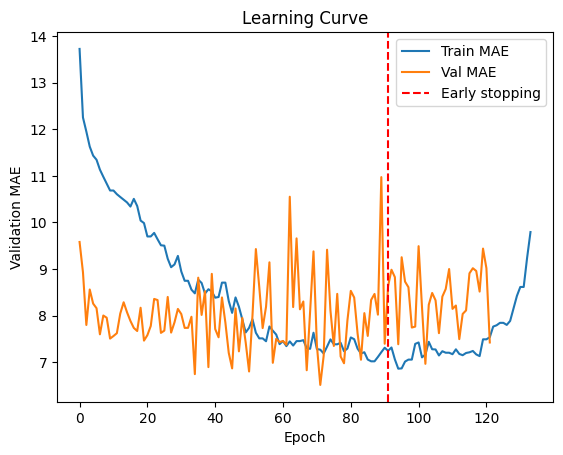

In [17]:
view_learning_curve("experiments/dcrnn_DR_3_h_24_32-32_lr_0.01_bs_64_0311152025/info.log")

Available keys: ['prediction', 'truth']
prediction: shape (24, 832, 92)
truth: shape (24, 832, 92)


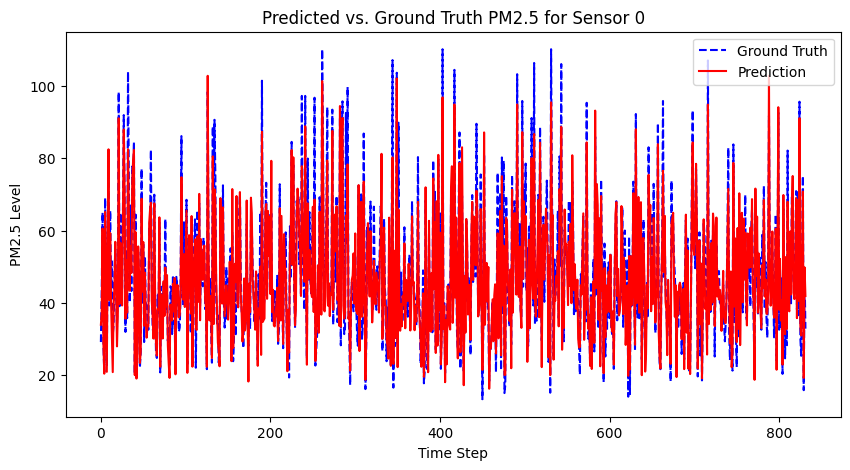

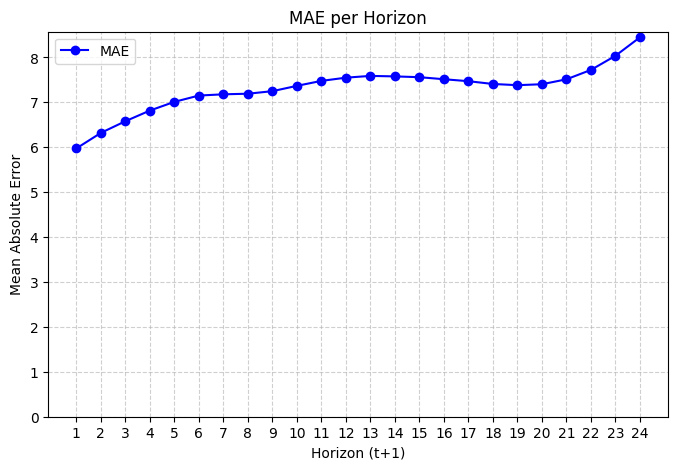

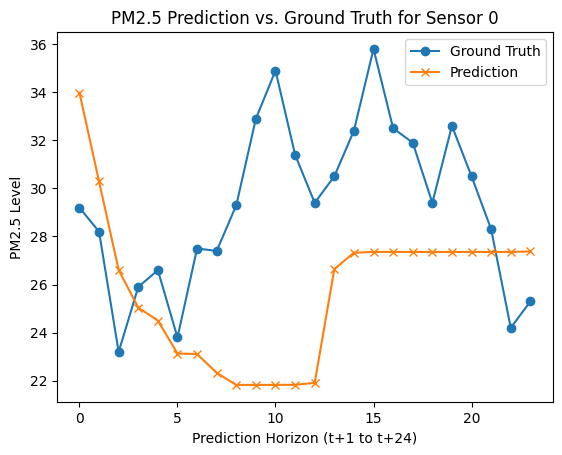

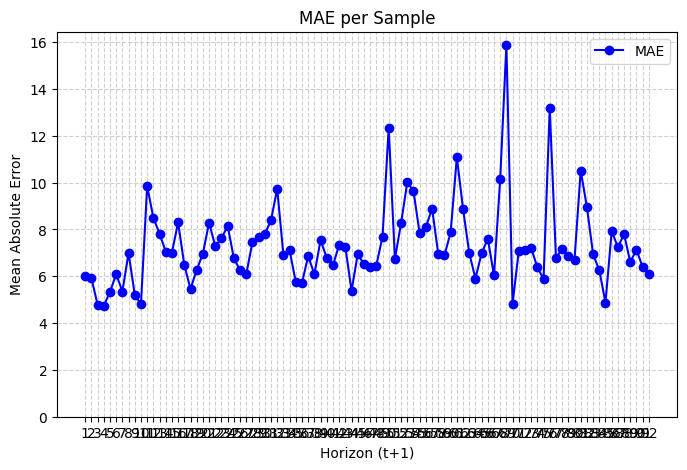

In [18]:
visualize("data/predictions/train_dcrnn_predictions.npz")

Available keys: ['prediction', 'truth']
prediction: shape (24, 256, 92)
truth: shape (24, 256, 92)


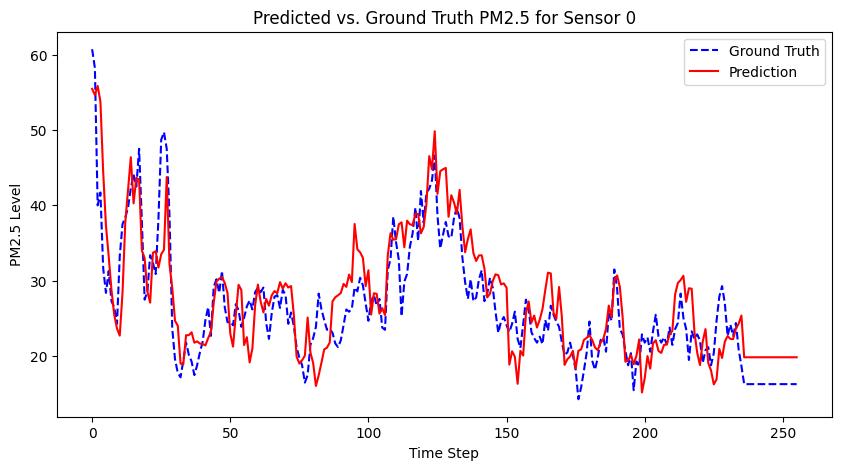

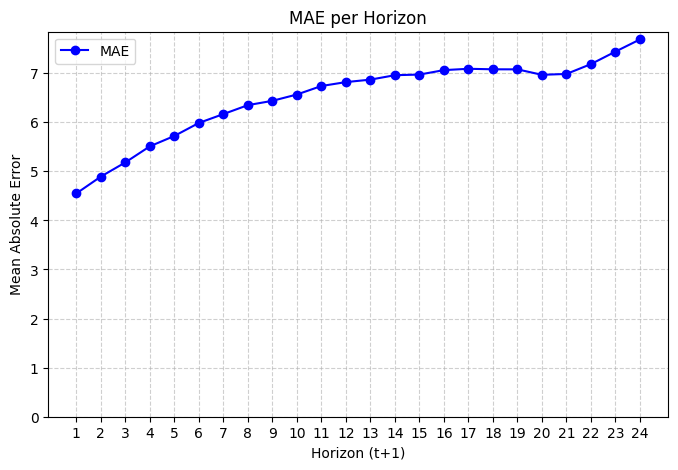

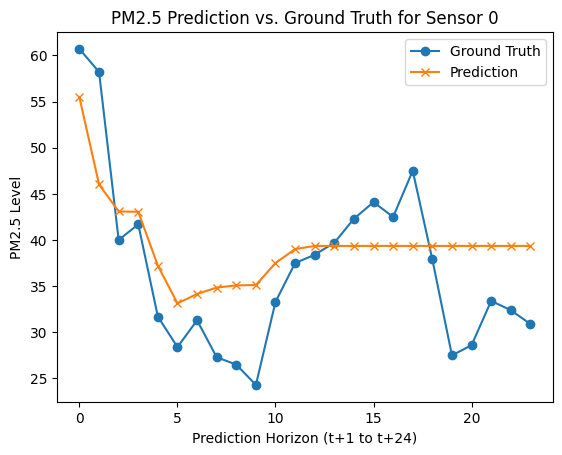

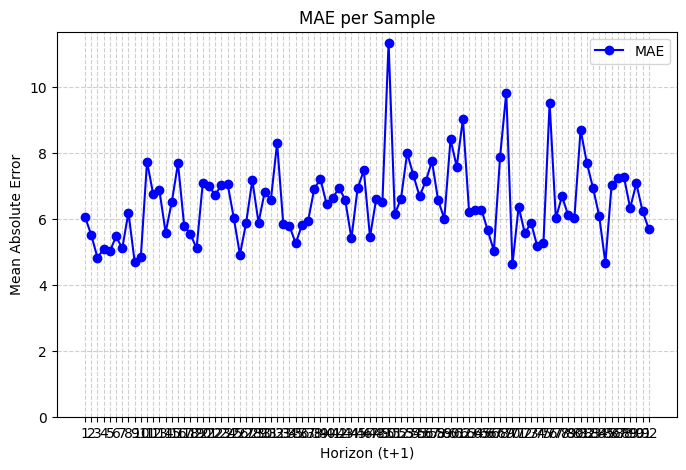

In [19]:
visualize("data/predictions/val_dcrnn_predictions.npz")

Available keys: ['prediction', 'truth']
prediction: shape (24, 128, 92)
truth: shape (24, 128, 92)


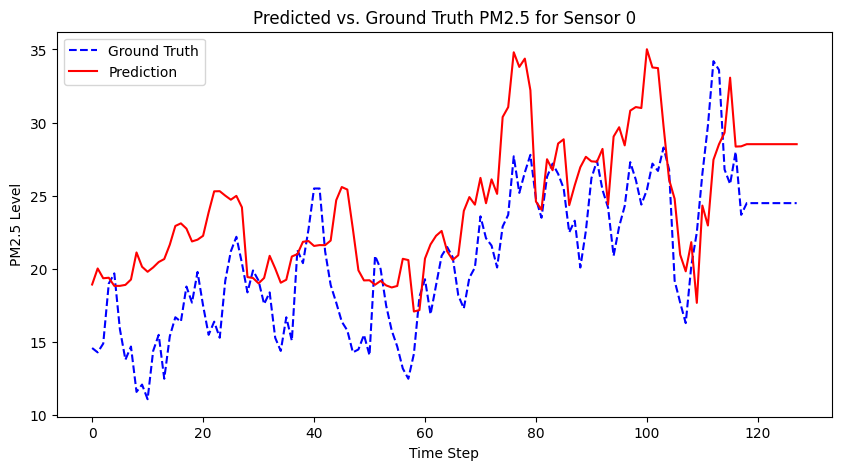

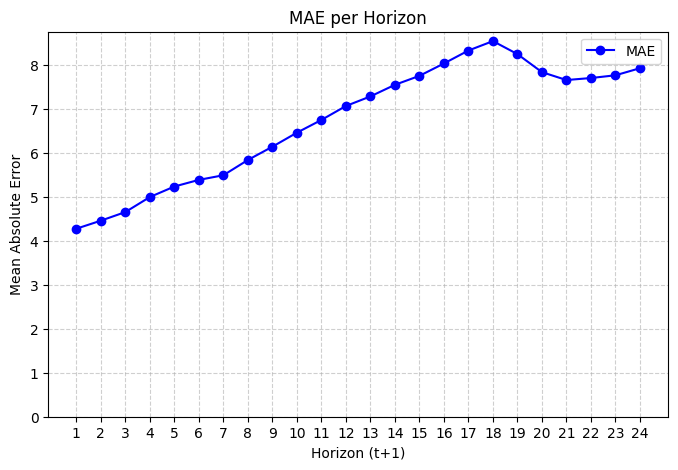

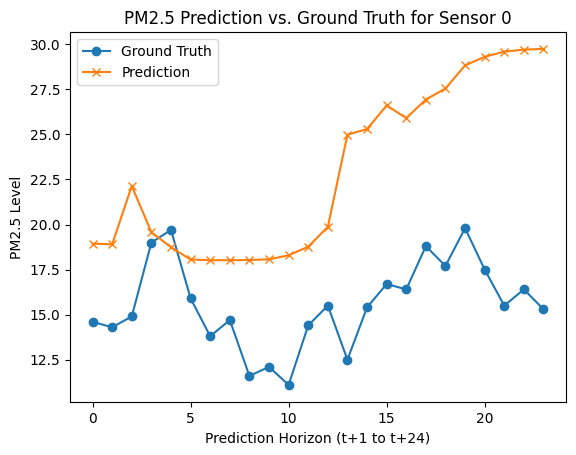

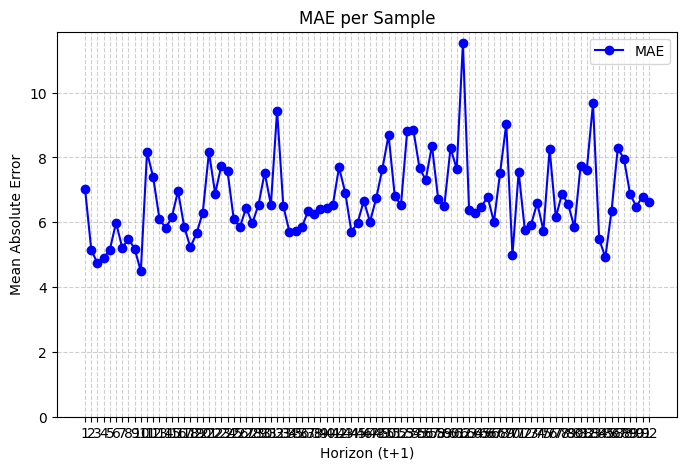

In [20]:
visualize("data/predictions/test_dcrnn_predictions.npz")

# Dimension meaning:

### Object: shape (horizon: h, num_sample: n, num_nodes: s)

- horizon: Each slice h = [0-23] correspond to the value at t+1+h tiemstep 
- num_sample: Each slice n = [0-191] correspond to the n starting position on the data
- num_nodes: Each slice s = [0-91] correspond to the 92 weather stations

### Usefully,

#### [:,i,j]: 
- gives all 24 timestep predictions where data is given to the model upto the ith timestep
- varying i shows how recursive predictions worsen over time
#### [i,:,j]: 
- gives all 192 timestep predictions where those prediction is at timestep t+1+i
- varying i shows the result at different starting points

### Expectation

- The MAE at horizon should have as little upward slope as possible with increasing timestep
- The MAE at samples should not increase much as sample goes forward as it indicates overfitting

# Save good model and Delete unnecessary models

In [21]:
def save_model(nickname,input_address,output_directory):
    """Save the model along with the current config file to a folder"""
    # Create the new directory path
    new_folder = os.path.join(output_directory, nickname)
    os.makedirs(new_folder, exist_ok=True)  # Create folder if it doesn't exist

    # Copy the config.yaml file
    config_source = "config.yaml"
    if os.path.exists(config_source):
        shutil.copy(config_source, new_folder)
    else:
        print(f"Warning: {config_source} not found.")

    # Copy the input file
    if os.path.exists(input_address):
        shutil.copy(input_address, new_folder)
    else:
        print(f"Warning: {input_address} not found.")

    print(f"Setup complete. Files copied to {new_folder}")

In [22]:
save_model(nickname="seq_len_4",
           input_address=input_name,
           output_directory="legacy_models/")

Setup complete. Files copied to legacy_models/seq_len_4


In [23]:
delete()

All files in 'models/' have been removed.
